In [1]:
import numpy as np
import keras
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.datasets import mnist

In [13]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
train_images = X_train.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = X_test.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

train_labels = y_train
test_labels = y_test

In [14]:
class DenseLayer:
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation
        self.W = keras.Variable(shape=(input_size, output_size), initializer="uniform")
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        x = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        return [self.W, self.b]

In [15]:
D1 = DenseLayer(input_size=2 * 2, output_size=6, activation=keras.ops.relu)
D1.weights

[<Variable path=variable_6, shape=(4, 6), dtype=float32, value=[[-0.02467012  0.02679029 -0.01952674 -0.04406555 -0.0412517  -0.03606283]
  [ 0.02646165 -0.01865222 -0.00884401 -0.00555808 -0.03297492  0.00976993]
  [ 0.02581718  0.00946568  0.0308833   0.04522191  0.03073982 -0.04178387]
  [ 0.02440273  0.02303132  0.027759   -0.04613736  0.03530383  0.02367723]]>,
 <Variable path=variable_7, shape=(6,), dtype=float32, value=[0. 0. 0. 0. 0. 0.]>]

In [16]:
class SequentialModel:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [17]:


from tensorflow.keras.layers import Dropout

model = SequentialModel(
    [
        DenseLayer(input_size=28 * 28, output_size=512, activation=keras.ops.relu),
        Dropout(0.5),
        DenseLayer(input_size=512, output_size=10, activation=keras.ops.softmax),
    ]
)
len(model.weights) == 4

True

In [18]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        print("Len check", len(images) == len(labels))
        self.index = 0
        self.images = images
        self.labels = labels
        indices = np.random.permutation(len(self.images))
        self.images = self.images[indices]
        self.labels = self.labels[indices]
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)


    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

In [19]:
learning_rate = 1.0
def update_weights(gradients, weights):
    keras.optimizers.SGD(learning_rate=learning_rate).apply_gradients(zip(gradients, weights))
    #for g, w in zip(gradients, weights):
    #    w.assign(w - g * learning_rate)

In [20]:
def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        loss = keras.ops.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = keras.ops.mean(loss)
        gradients = tape.gradient(average_loss, model.weights)
        update_weights(gradients, model.weights)
        return average_loss

In [21]:
def fit(model, images, labels, epochs):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")
        y_pred = model(train_images)
        pred_lab = keras.ops.argmax(y_pred, axis=1)
        matches_t = pred_lab == train_labels
        print(f"Validation accuracy: {keras.ops.mean(matches_t):.4f}")
        predictions = model(test_images)
        predicted_labels = keras.ops.argmax(predictions, axis=1)
        matches = predicted_labels == test_labels
        print(f"Test accuracy: {keras.ops.mean(matches):.4f}")
        print()

In [22]:
fit(model, train_images, train_labels, epochs=10)
y_pred = model(train_images)
pred_lab = keras.ops.argmax(y_pred, axis=1)
matches_t = pred_lab == train_labels
f"Train accuracy: {keras.ops.mean(matches_t):.4f}"

Epoch 0
Len check True
loss at batch 0: 2.33
loss at batch 100: 0.28
loss at batch 200: 0.22
loss at batch 300: 0.27
loss at batch 400: 0.12
Validation accuracy: 0.9626
Test accuracy: 0.9579

Epoch 1
Len check True
loss at batch 0: 0.09
loss at batch 100: 0.08
loss at batch 200: 0.14
loss at batch 300: 0.16
loss at batch 400: 0.06
Validation accuracy: 0.9764
Test accuracy: 0.9709

Epoch 2
Len check True
loss at batch 0: 0.04
loss at batch 100: 0.04
loss at batch 200: 0.06
loss at batch 300: 0.08
loss at batch 400: 0.05
Validation accuracy: 0.9874
Test accuracy: 0.9779

Epoch 3
Len check True
loss at batch 0: 0.04
loss at batch 100: 0.09
loss at batch 200: 0.03
loss at batch 300: 0.10
loss at batch 400: 0.02
Validation accuracy: 0.9872
Test accuracy: 0.9752

Epoch 4
Len check True
loss at batch 0: 0.03
loss at batch 100: 0.02
loss at batch 200: 0.02
loss at batch 300: 0.03
loss at batch 400: 0.02
Validation accuracy: 0.9899
Test accuracy: 0.9766

Epoch 5
Len check True
loss at batch 0: 

'Train accuracy: 0.9992'

In [23]:
predictions = model(test_images)
predicted_labels = keras.ops.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
f"accuracy: {keras.ops.mean(matches):.4f}"

'accuracy: 0.9827'

<Axes: >

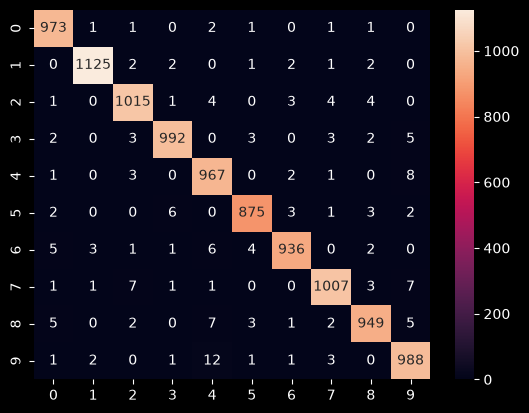

In [24]:
# y_pred is your model's predictions, y_test is the actual labels
cm = confusion_matrix(y_test, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d')

1 tf.Tensor(2, shape=(), dtype=int32)


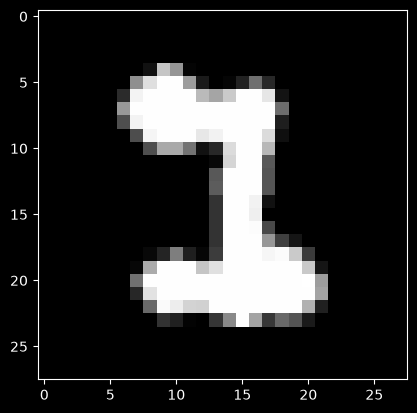

1 tf.Tensor(2, shape=(), dtype=int32)


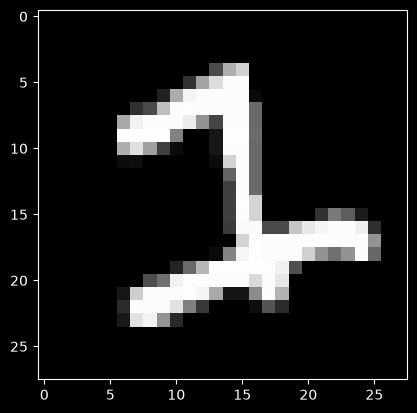

In [25]:
import matplotlib.pyplot as plt
indx = np.where(predicted_labels != test_labels)[0]

for ind in indx:
    if not(predicted_labels[ind] == 2 and y_test[ind] == 1):
        continue
    print(y_test[ind], predicted_labels[ind])
    plt.imshow(X_test[ind], cmap="grey")
    plt.show()
